# Bloc 3A — Prevision des volumes entrants

Analyse exploratoire de `features_journalier` (grain journalier) et diagnostic
d'apprentissage du candidat XGBoost utilise dans l'Ensemble SARIMA+XGBoost
retenu pour la prevision de `volume_entrant_jour` (nombre de dossiers recus
par jour, tous services confondus). Le detail de la comparaison des 4
candidats (Prophet/SARIMA/XGBoost/Ensemble) est dans
`docs/AMELIORATION_MODELES.md` ; ce notebook se concentre sur ce que les
donnees montrent en amont, et sur le comportement du modele quand on fait
varier la quantite de donnees d'entrainement.

In [1]:
from _setup import engine, save, COULEUR_PRINCIPALE, COULEUR_ALERTE, COULEUR_NEUTRE, PALETTE_CATEGORIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

BLOC = "volumes"
TARGET = "volume_entrant_jour"

df = pd.read_sql("SELECT * FROM features_journalier", engine, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
# Les colonnes de lag arrivent en NUMERIC (Decimal) depuis Postgres : on les
# repasse en float des le chargement, une seule fois, plutot que de le refaire
# a chaque cellule.
for c in df.columns:
    if c != "date":
        df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"{len(df)} jours, du {df['date'].min().date()} au {df['date'].max().date()}")
print(f"jours_semaine presents : {sorted(df['jour_semaine'].unique())} (0=lundi) -- confirme que seuls les jours ouvres sont extraits")
manquants = (df.isna().mean() * 100).round(2)
print("\nColonnes avec valeurs manquantes :")
print(manquants[manquants > 0])

640 jours, du 2024-01-01 au 2026-06-12
jours_semaine presents : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (0=lundi) -- confirme que seuls les jours ouvres sont extraits

Colonnes avec valeurs manquantes :
volume_lag_1j     0.16
etp_lag_1j        0.16
volume_lag_7j     1.09
etp_lag_7j        1.09
volume_lag_14j    2.19
etp_lag_14j       2.19
volume_lag_30j    4.69
etp_lag_30j       4.69
dtype: float64


**Lecture.** Le jeu couvre 640 jours ouvres, du 1er janvier 2024 au 12 juin
2026 -- uniquement des jours 0 a 4 (lundi-vendredi), les week-ends n'existent
pas dans `features_journalier`. Les seules colonnes incompletes sont les lags
(`volume_lag_30j` a 4.7% de manquants au maximum), ce qui est attendu : les 30
premiers jours de la serie n'ont pas de lag a 30 jours disponible. Aucune
valeur manquante ailleurs, donc pas de nettoyage a prevoir avant modelisation
sur ce bloc.

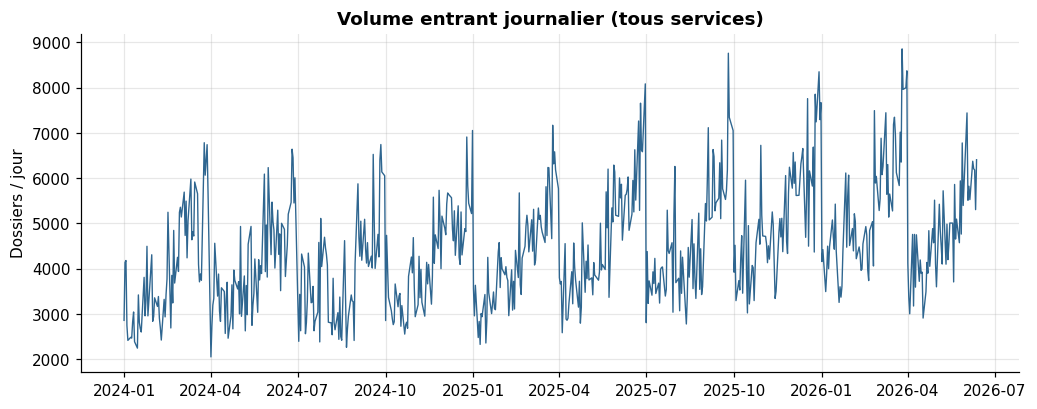

count     640.0
mean     4477.1
std      1273.1
min      2051.0
25%      3495.5
50%      4305.0
75%      5258.5
max      8854.0
Name: volume_entrant_jour, dtype: float64


In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df["date"], df[TARGET], color=COULEUR_PRINCIPALE, linewidth=0.9)
ax.set_title("Volume entrant journalier (tous services)")
ax.set_ylabel("Dossiers / jour")
save(fig, BLOC, "01_serie_temporelle.png")
plt.show()

print(df[TARGET].describe().round(1))

**Lecture.** La moyenne se situe a 4477 dossiers/jour pour un ecart-type de
1273 (coefficient de variation ~28%), avec un minimum a 2051 et un maximum a
8854. Cet ecart entre min et max (facteur 4) existe deja avant tout decoupage
par jour de semaine ou par mois : une part importante de la variabilite tient
a des pics ponctuels visibles sur la courbe plutot qu'a une tendance de fond
qui se deplacerait lentement -- la serie oscille autour d'un niveau plutot
stable sur les deux ans et demi, sans derive nette.

C:\Users\akbre\AppData\Local\Temp\ipykernel_32048\4028550304.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_par_jour, labels=labels_jours, patch_artist=True)


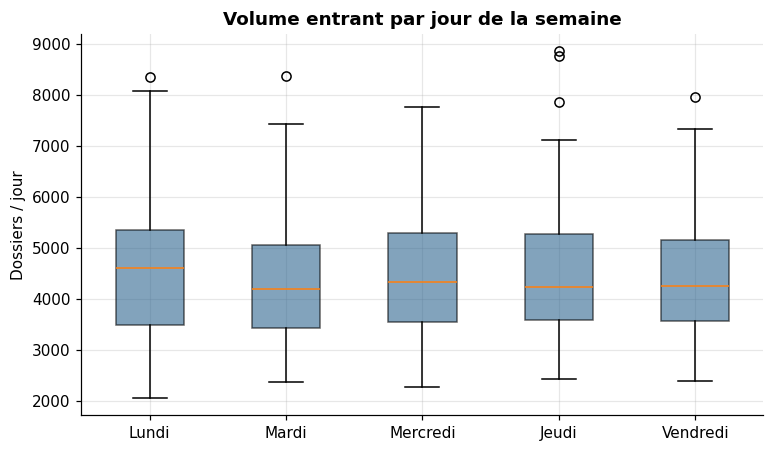

jour_semaine
0    4568.0
1    4400.3
2    4520.9
3    4512.5
4    4383.5
Name: volume_entrant_jour, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels_jours = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi"]
data_par_jour = [df.loc[df["jour_semaine"] == j, TARGET].values for j in range(5)]
bp = ax.boxplot(data_par_jour, labels=labels_jours, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor(COULEUR_PRINCIPALE)
    patch.set_alpha(0.6)
ax.set_title("Volume entrant par jour de la semaine")
ax.set_ylabel("Dossiers / jour")
save(fig, BLOC, "02_boxplot_jour_semaine.png")
plt.show()

print(df.groupby("jour_semaine")[TARGET].mean().round(1))

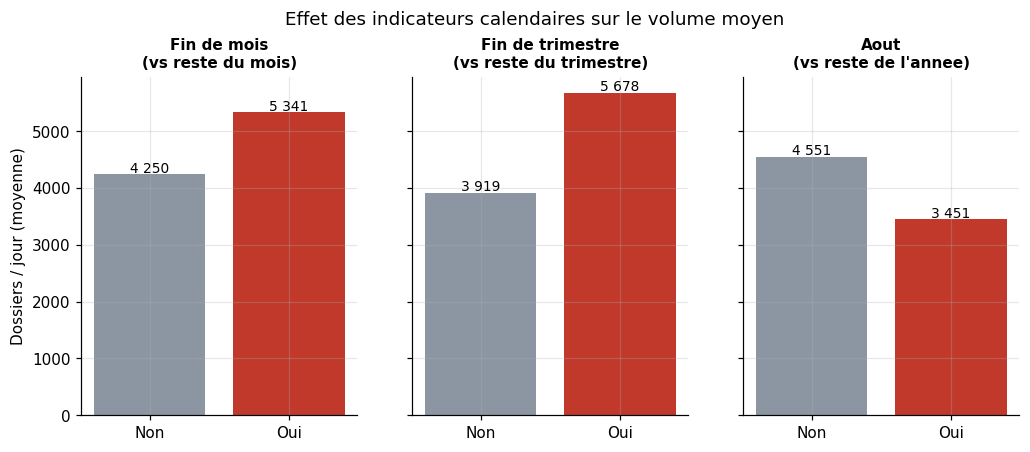

In [4]:
effets = {
    "Fin de mois\n(vs reste du mois)": df.groupby("est_fin_de_mois")[TARGET].mean(),
    "Fin de trimestre\n(vs reste du trimestre)": df.groupby("est_fin_trimestre")[TARGET].mean(),
    "Aout\n(vs reste de l'annee)": df.groupby(df["mois"] == 8)[TARGET].mean(),
}
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)
for ax, (titre, serie) in zip(axes, effets.items()):
    vals = [serie.iloc[0], serie.iloc[1]]
    ax.bar(["Non", "Oui"], vals, color=[COULEUR_NEUTRE, COULEUR_ALERTE])
    ax.set_title(titre, fontsize=10)
    for i, v in enumerate(vals):
        ax.text(i, v + 30, f"{v:,.0f}".replace(",", " "), ha="center", fontsize=9)
axes[0].set_ylabel("Dossiers / jour (moyenne)")
fig.suptitle("Effet des indicateurs calendaires sur le volume moyen", y=1.03)
save(fig, BLOC, "03_effets_calendaires.png")
plt.show()

**Lecture.** Le decoupage par jour de semaine est presque plat (de 4384 le
vendredi a 4568 le lundi, un ecart de moins de 5% entre le plus haut et le plus bas) : une fois qu'on s'est
deja restreint aux jours ouvres, le jour de la semaine en lui-meme n'apporte
quasiment rien. Les indicateurs calendaires "de cycle" racontent une tout
autre histoire : le volume moyen passe de 4250 a 5341 dossiers en fin de
mois (+25.7%), et de 3919 a 5678 en fin de trimestre (+44.9%) -- coherent
avec l'hypothese deja posee dans `AMELIORATION_MODELES.md` d'un effet de
cloture comptable qui s'etale sur plusieurs jours plutot que de se
concentrer sur une seule date. A l'inverse, aout tire le volume vers le bas
(4551 -> 3451, soit -24.2%), signature classique d'une periode de conges. Ces
trois effets, plus marques que celui du jour de semaine, expliquent pourquoi
les regresseurs exogenes ont fait chuter le MAE de 34.5% des leur ajout au
SARIMA (cf. Etape 2 de `AMELIORATION_MODELES.md`).

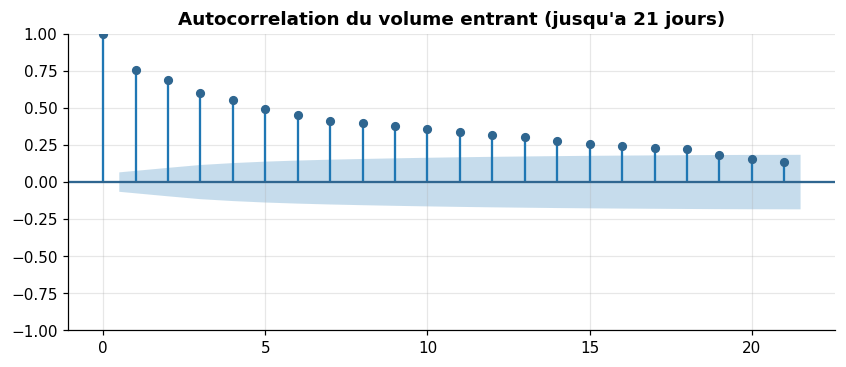

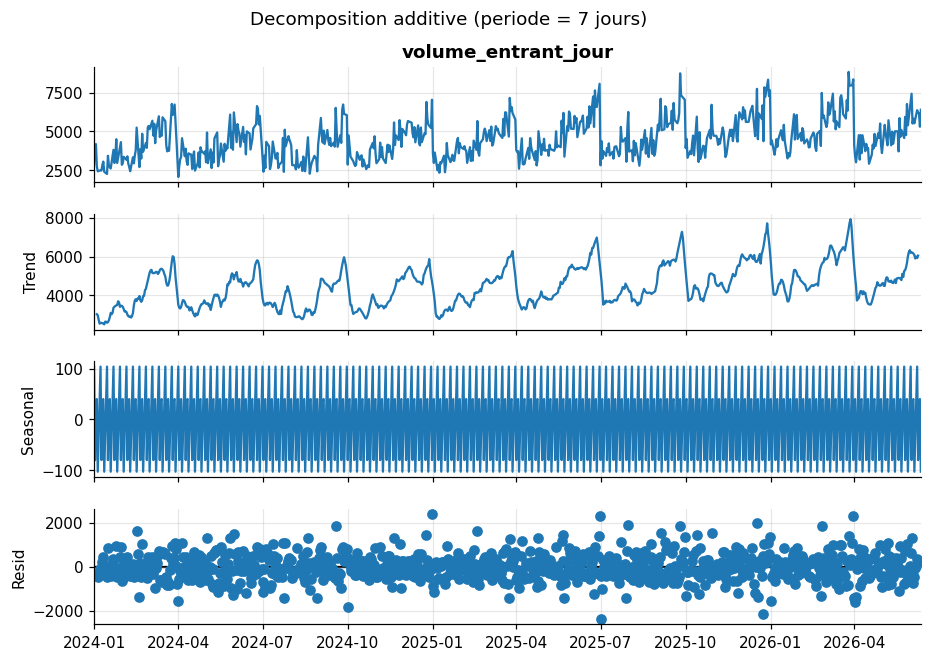

Part de variance non expliquee par tendance+saisonnalite(7j) : 23.3%
Amplitude de la composante saisonniere : 206 dossiers (a comparer a l'ecart-type total de 1227)


In [5]:
serie = df.set_index("date")[TARGET].asfreq("D").interpolate()

fig, ax = plt.subplots(figsize=(9, 3.5))
plot_acf(serie, lags=21, ax=ax, color=COULEUR_PRINCIPALE)
ax.set_title("Autocorrelation du volume entrant (jusqu'a 21 jours)")
save(fig, BLOC, "04_autocorrelation.png")
plt.show()

decomp = seasonal_decompose(serie, model="additive", period=7)
fig = decomp.plot()
fig.set_size_inches(9, 6)
fig.suptitle("Decomposition additive (periode = 7 jours)", y=1.01)
save(fig, BLOC, "05_decomposition_saisonniere.png")
plt.show()

part_residuelle = decomp.resid.dropna().var() / serie.var()
amplitude_saisonniere = decomp.seasonal.max() - decomp.seasonal.min()
print(f"Part de variance non expliquee par tendance+saisonnalite(7j) : {part_residuelle*100:.1f}%")
print(f"Amplitude de la composante saisonniere : {amplitude_saisonniere:.0f} dossiers (a comparer a l'ecart-type total de {serie.std():.0f})")

**Lecture.** L'autocorrelation retombe vite : 0.76 a un jour d'ecart, 0.41 a
sept jours, 0.28 a deux semaines, 0.14 a trois semaines. Il y a bien un echo
hebdomadaire (le pic local a 7 et 14 jours sur le correlogramme le confirme),
mais il est nettement plus faible que la simple memoire d'un jour sur
l'autre -- la serie n'a pas de memoire longue. La decomposition saisonniere
va dans le meme sens : la composante saisonniere hebdomadaire ne pese que 206
dossiers d'amplitude, contre un ecart-type total de 1227 (serie interpolee sur tous les jours calendaires, y compris week-ends), et le residu a lui
seul represente 23.3% de la variance de la serie. Autrement dit, meme en
retirant parfaitement la tendance et la saisonnalite hebdomadaire, il reste
une part de variabilite consequente que ni l'une ni l'autre n'expliquent --
la meme observation, formulee autrement, que le "bruit metier reel" deja
identifie dans `AMELIORATION_MODELES.md` (campagnes commerciales, evenements
ponctuels, sans trace dans les colonnes disponibles).

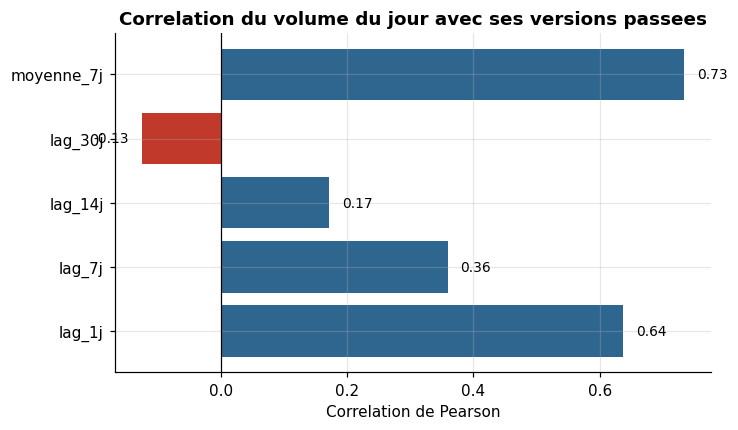

In [6]:
corrs = {f"lag_{l}j": df[TARGET].corr(df[f"volume_lag_{l}j"]) for l in [1, 7, 14, 30]}
corrs["moyenne_7j"] = df[TARGET].corr(df["volume_moy_7j"])

fig, ax = plt.subplots(figsize=(7, 4))
noms, valeurs = list(corrs.keys()), list(corrs.values())
couleurs = [COULEUR_ALERTE if v < 0 else COULEUR_PRINCIPALE for v in valeurs]
ax.barh(noms, valeurs, color=couleurs)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation du volume du jour avec ses versions passees")
ax.set_xlabel("Correlation de Pearson")
for i, v in enumerate(valeurs):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f"{v:.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=9)
save(fig, BLOC, "06_correlations_lags.png")
plt.show()

**Lecture.** La moyenne mobile a 7 jours est la variable la plus correlee au
volume du jour (0.73), devant meme le lag brut a 1 jour (0.64). Le lag a 30
jours, lui, est quasi decorrele (-0.13) : au-dela d'un mois, connaitre le
volume d'un jour passe ne dit plus rien d'utile sur aujourd'hui. Ce classement
explique directement pourquoi une moyenne mobile 7 jours sans aucun modele
obtient un MAE quasi identique a l'Ensemble SARIMA+XGBoost (647.0 contre 644.7
dans `AMELIORATION_MODELES.md`) : la variable la plus informative de tout le
bloc est aussi la plus simple a calculer, et les modeles plus sophistiques
servent surtout a capter le reste -- fin de mois, fin de trimestre, aout --
plutot qu'a ameliorer la lecture du passe recent.

## Courbe d'apprentissage (candidat XGBoost)

SARIMA n'a pas de notion standard de "reentrainement incremental sur des
tailles de train croissantes" (c'est un modele d'etat, pas un estimateur
generique compatible avec `sklearn.model_selection.learning_curve`), donc la
courbe d'apprentissage ci-dessous porte sur le second candidat du bloc : le
XGBoost entraine sur les features de lag, avec les hyperparametres retenus
dans `models/model_volumes.pkl` (`max_depth=4`, `learning_rate=0.05`,
`n_estimators=146`). Elle est construite en fenetre **expansive et
chronologique** (on entraine sur les N premiers jours du train, jamais un
echantillon aleatoire) et evaluee sur le meme jeu de validation fixe a chaque
taille -- melanger les jours comme le ferait `learning_curve` par defaut
romprait l'ordre temporel et fausserait completement le diagnostic.

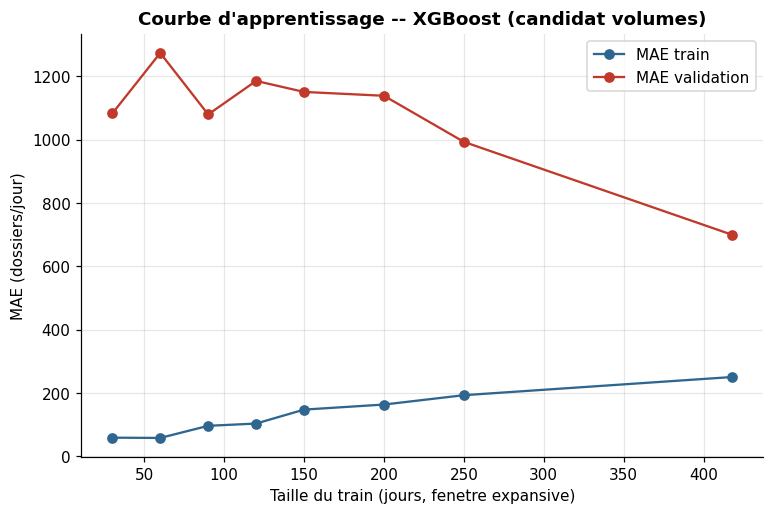

taille=  30  MAE_train=   59.1  MAE_val= 1083.0
taille=  60  MAE_train=   58.2  MAE_val= 1274.1
taille=  90  MAE_train=   96.5  MAE_val= 1080.0
taille= 120  MAE_train=  103.7  MAE_val= 1185.8
taille= 150  MAE_train=  147.7  MAE_val= 1151.0
taille= 200  MAE_train=  163.7  MAE_val= 1138.9
taille= 250  MAE_train=  193.2  MAE_val=  993.3
taille= 418  MAE_train=  250.6  MAE_val=  699.7


In [7]:
import sys
from _setup import PROJECT_ROOT
sys.path.insert(0, str(PROJECT_ROOT / "notebooks_avec_ecriture_dans_database"))
from modelisation_common import calculer_features_incidents, split_temporel
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

FEATURES_XGB = [
    "volume_lag_1j", "volume_lag_7j", "volume_lag_14j", "volume_lag_30j", "volume_moy_7j",
    "jour_semaine", "mois", "trimestre", "semaine_du_mois",
    "est_fin_de_mois", "est_fin_trimestre", "est_lundi", "est_vendredi", "est_aout",
    "nb_etp_impactes_jour", "volume_annonce_jour",
]
df["est_aout"] = (df["date"].dt.month == 8).astype(int)
df = df.merge(calculer_features_incidents(df["date"], engine), on="date", how="left")

df_xgb = df.dropna(subset=FEATURES_XGB + [TARGET]).copy()
df_train, df_val, _df_test = split_temporel(df)
date_fin_train, date_fin_val = df_train["date"].max(), df_val["date"].max()
df_train_x = df_xgb[df_xgb["date"] <= date_fin_train].reset_index(drop=True)
df_val_x = df_xgb[(df_xgb["date"] > date_fin_train) & (df_xgb["date"] <= date_fin_val)]

tailles = [30, 60, 90, 120, 150, 200, 250, len(df_train_x)]
mae_train, mae_val = [], []
for taille in tailles:
    sous_train = df_train_x.iloc[:taille]
    m = XGBRegressor(n_estimators=146, max_depth=4, learning_rate=0.05, subsample=0.8,
                      colsample_bytree=1.0, min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0,
                      random_state=42, verbosity=0)
    m.fit(sous_train[FEATURES_XGB], sous_train[TARGET])
    mae_train.append(mean_absolute_error(sous_train[TARGET], m.predict(sous_train[FEATURES_XGB])))
    mae_val.append(mean_absolute_error(df_val_x[TARGET], m.predict(df_val_x[FEATURES_XGB])))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tailles, mae_train, marker="o", color=COULEUR_PRINCIPALE, label="MAE train")
ax.plot(tailles, mae_val, marker="o", color=COULEUR_ALERTE, label="MAE validation")
ax.set_xlabel("Taille du train (jours, fenetre expansive)")
ax.set_ylabel("MAE (dossiers/jour)")
ax.set_title("Courbe d'apprentissage -- XGBoost (candidat volumes)")
ax.legend()
save(fig, BLOC, "07_courbe_apprentissage.png")
plt.show()

for t, tr, va in zip(tailles, mae_train, mae_val):
    print(f"taille={t:4d}  MAE_train={tr:7.1f}  MAE_val={va:7.1f}")

**Lecture.** Sur les 30 premiers jours de train, XGBoost memorise
quasiment le bruit (MAE train = 59) sans generaliser (MAE validation = 1083)
: avec une profondeur maximale de 4 et si peu de points, l'arbre a largement
la capacite de coller aux donnees plutot que d'apprendre une regle
generale -- c'est du surapprentissage manuel, pas un probleme du modele final.
A mesure que le train grandit, le MAE train augmente regulierement (59 -> 251
a taille complete) : c'est le signe attendu que le modele ne peut plus
interpoler parfaitement une serie plus longue et plus variee, couvrant
desormais plusieurs fins de trimestre et un mois d'aout complet. Le MAE
validation baisse globalement (1083 -> 700) mais pas de facon reguliere -- il
remonte meme a 1274 a 60 jours, avant de redescendre : a cette taille, le
train ne couvre encore aucune fin de trimestre, ce qui rend chaque
prediction sur la periode de validation instable des qu'un cycle comptable
apparait sans avoir ete vu a l'entrainement. L'ecart residuel a taille
maximale (251 en train contre 700 en validation) reste net, mais il rejoint
d'assez pres le MAE test de 690 obtenu par le meme candidat dans le pipeline
de production (`model_volumes.pkl`) -- un ecart qui, au vu de la section
precedente, tient pour une bonne part au bruit non explique par les colonnes
disponibles plutot qu'a un manque de donnees. C'est aussi ce qui justifie
que le modele retenu en production ne soit pas XGBoost seul mais un ensemble
avec SARIMA, qui stabilise la partie tendance/saisonnalite que XGBoost, sur
si peu de jours, a plus de mal a capter seul.

## Synthese du bloc

Les donnees confirment ce que `AMELIORATION_MODELES.md` observait deja au
niveau des metriques : le signal exploitable dans `features_journalier` tient
surtout a la memoire courte (moyenne mobile 7 jours, lag 1 jour) et a trois
ruptures de calendrier (fin de mois, fin de trimestre, aout), le jour de la
semaine pris isolement n'apportant presque rien une fois qu'on s'est deja
restreint aux jours ouvres. La courbe d'apprentissage du candidat XGBoost
montre un surapprentissage attendu sur petits echantillons qui se resorbe
progressivement avec la taille du train, sans jamais totalement disparaitre
-- coherent avec un residu de variance qui releve, pour une bonne part, de
facteurs absents des donnees plutot que d'un manque d'exemples.